# Notebook 3: Sentiment Analysis

## Purpose
Classify each KFC Trustpilot review as **Positive**, **Negative**, or **Neutral**.

## Key Difference from Reddit Version
- Trustpilot provides **star ratings** (1-5), so we can use these as ground-truth labels instead of manual labelling
- Stars 1-2 = Negative, Star 3 = Neutral, Stars 4-5 = Positive
- We still train the same models to compare against the star-based labels

## Input
`kfc_tp_preprocessed_sentiment.csv` (from Notebook 2)

## Output
- `kfc_tp_sentiment_labelled_full.csv`
- `sentiment_distribution.png`

## Step 0 - Import Libraries

In [ ]:
!pip install pandas numpy scikit-learn imbalanced-learn transformers torch matplotlib

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from transformers import pipeline
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
print("Libraries loaded.")

Libraries loaded.


## Step 1 - Load Data and Create Star-Based Labels

In [ ]:
df = pd.read_csv("kfc_tp_preprocessed_sentiment.csv")
print(f"Loaded: {len(df)} reviews")

# Create sentiment labels from star ratings
# 1-2 stars = Negative, 3 stars = Neutral, 4-5 stars = Positive
def star_to_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df["Star_Label"] = df["Star Rating"].apply(star_to_sentiment)

print(f"\nStar-based label distribution:")
print(df["Star_Label"].value_counts())

Loaded: 200 reviews

Star-based label distribution:
Star_Label
Negative    138
Positive     58
Neutral       4
Name: count, dtype: int64


## Step 2 - Train/Test Split (60/40)

We use the star-based labels as our ground truth for evaluation.

In [ ]:
X = df["Tokenised_Review"]
y = df["Star_Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 120 | Test: 80


## Step 3 - Traditional Models (Logistic Regression + Naive Bayes)

In [ ]:
# Vectorise
vectorizer = CountVectorizer(max_features=5000)
X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow  = vectorizer.transform(X_test)

# SMOTE
# The 'Neutral' class likely has only 2 samples in the training set due to stratification.
# To resolve the "n_neighbors <= n_samples_fit" error, we set k_neighbors to 1.
smote = SMOTE(random_state=42, k_neighbors=1)
X_bal, y_bal = smote.fit_resample(X_train_bow, y_train)
print("After SMOTE:")
print(pd.Series(y_bal).value_counts())

After SMOTE:
Star_Label
Negative    83
Positive    83
Neutral     83
Name: count, dtype: int64


In [ ]:
# Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_bal, y_bal)
lr_acc = accuracy_score(y_test, lr.predict(X_test_bow))
print(f"Accuracy: {lr_acc:.3f}")
print(classification_report(y_test, lr.predict(X_test_bow)))

Training Logistic Regression...
Accuracy: 0.787
              precision    recall  f1-score   support

    Negative       0.95      0.76      0.85        55
     Neutral       0.10      0.50      0.17         2
    Positive       0.77      0.87      0.82        23

    accuracy                           0.79        80
   macro avg       0.61      0.71      0.61        80
weighted avg       0.88      0.79      0.82        80



In [ ]:
# Naive Bayes
print("Training Naive Bayes...")
nb = MultinomialNB()
nb.fit(X_bal, y_bal)
nb_acc = accuracy_score(y_test, nb.predict(X_test_bow))
print(f"Accuracy: {nb_acc:.3f}")
print(classification_report(y_test, nb.predict(X_test_bow)))

Training Naive Bayes...
Accuracy: 0.900
              precision    recall  f1-score   support

    Negative       0.91      0.95      0.93        55
     Neutral       0.00      0.00      0.00         2
    Positive       0.87      0.87      0.87        23

    accuracy                           0.90        80
   macro avg       0.59      0.61      0.60        80
weighted avg       0.88      0.90      0.89        80



## Step 4 - Transformer Models (RoBERTa + BERTweet)

In [ ]:
def map_label(label_str):
    l = label_str.lower()
    if "neg" in l or "label_0" in l: return "Negative"
    elif "pos" in l or "label_2" in l: return "Positive"
    else: return "Neutral"

In [ ]:
# RoBERTa
print("Loading RoBERTa...")
roberta = pipeline("sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    max_length=512, truncation=True)

print("Running on test set...")
rob_preds = [map_label(roberta(str(t)[:512])[0]["label"]) for t in X_test]
rob_acc = accuracy_score(y_test, rob_preds)
print(f"RoBERTa Accuracy: {rob_acc:.3f}")
print(classification_report(y_test, rob_preds))

Loading RoBERTa...


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Running on test set...
RoBERTa Accuracy: 0.838
              precision    recall  f1-score   support

    Negative       0.98      0.89      0.93        55
     Neutral       0.08      0.50      0.14         2
    Positive       0.94      0.74      0.83        23

    accuracy                           0.84        80
   macro avg       0.67      0.71      0.64        80
weighted avg       0.95      0.84      0.88        80



In [ ]:
# BERTweet
print("Loading BERTweet...")
bertweet = pipeline("sentiment-analysis",
    model="finiteautomata/bertweet-base-sentiment-analysis",
    max_length=128, truncation=True)

print("Running on test set...")
bw_preds = [map_label(bertweet(str(t)[:128])[0]["label"]) for t in X_test]
bw_acc = accuracy_score(y_test, bw_preds)
print(f"BERTweet Accuracy: {bw_acc:.3f}")
print(classification_report(y_test, bw_preds))

Loading BERTweet...


config.json:   0%|          | 0.00/949 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: finiteautomata/bertweet-base-sentiment-analysis
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Running on test set...
BERTweet Accuracy: 0.713
              precision    recall  f1-score   support

    Negative       0.97      0.71      0.82        55
     Neutral       0.00      0.00      0.00         2
    Positive       0.90      0.78      0.84        23

    accuracy                           0.71        80
   macro avg       0.62      0.50      0.55        80
weighted avg       0.93      0.71      0.81        80



## Step 5 - Model Comparison

In [ ]:
results = {"Logistic Regression": lr_acc, "Naive Bayes": nb_acc,
           "RoBERTa": rob_acc, "BERTweet": bw_acc}

print("MODEL COMPARISON")
print("=" * 40)
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    marker = " <-- BEST" if acc == max(results.values()) else ""
    print(f"  {name:25s}  {acc:.3f}{marker}")

MODEL COMPARISON
  Naive Bayes                0.900 <-- BEST
  RoBERTa                    0.838
  Logistic Regression        0.787
  BERTweet                   0.713


## Step 6 - Label Full Dataset with Naive Bayes (Highest Accuracy)

In [ ]:
# Prediction functions

print("Labelling full dataset with Naive Bayes")

# Vectorise ALL reviews using the same fitted vectorizer
X_all_bow = vectorizer.transform(df["Tokenised_Review"])

# Predict sentiment for every review
df["Sentiment"] = nb.predict(X_all_bow)

print(f"Done! Labelled {len(df)} reviews.")
print(f"\nSentiment breakdown:")
print(df["Sentiment"].value_counts())

Labelling full dataset with Naive Bayes
Done! Labelled 200 reviews.

Sentiment breakdown:
Sentiment
Negative    139
Positive     59
Neutral       2
Name: count, dtype: int64


## Step 7 - Visualise & Save

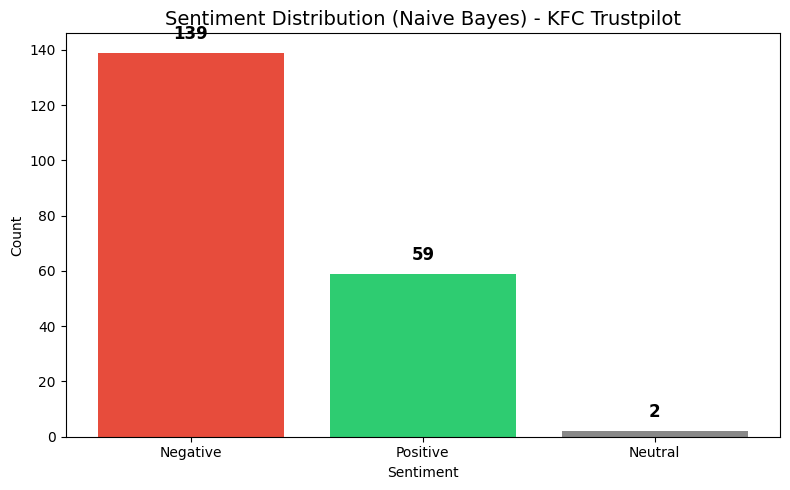

In [ ]:
counts = df["Sentiment"].value_counts()
colors = {"Neutral": "#888888", "Negative": "#E74C3C", "Positive": "#2ECC71"}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index, counts.values,
              color=[colors.get(c, "#3498DB") for c in counts.index])
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha="center", fontsize=12, fontweight="bold")
ax.set_title("Sentiment Distribution (Naive Bayes) - KFC Trustpilot", fontsize=14)
ax.set_xlabel("Sentiment"); ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("sentiment_distribution.png", dpi=150)
plt.show()

In [ ]:
df.to_csv("kfc_tp_sentiment_labelled_full.csv", index=False, encoding="utf-8-sig")
print(f"Saved: kfc_tp_sentiment_labelled_full.csv")
print(f"\nSentiment breakdown:")
print(df["Sentiment"].value_counts())

Saved: kfc_tp_sentiment_labelled_full.csv

Sentiment breakdown:
Sentiment
Negative    139
Positive     59
Neutral       2
Name: count, dtype: int64
